<a href="https://colab.research.google.com/github/ga-arsh/Demo/blob/main/IN_PROCESS_ENSEMBLE_MNIST_data_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [12]:
print("Loading MNIST data...")
mnist = fetch_openml('mnist_784', version=1)

Loading MNIST data...


In [13]:
x = mnist.data.astype(np.float32)
y = mnist.target.astype(int)

In [14]:
#preprocessing
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

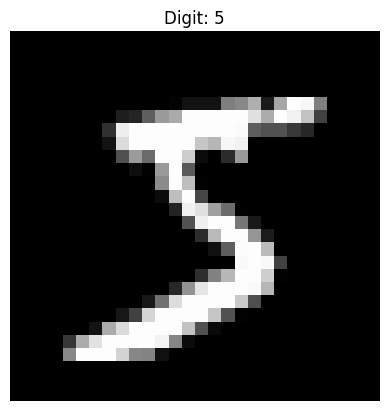

In [15]:
import matplotlib.pyplot as plt
# Select one image
image = x.iloc[0].values.reshape(28,28)

# Display image
plt.imshow(image, cmap='gray')

# Show label
plt.title(f"Digit: {y.iloc[0]}")

plt.axis('off')
plt.show()

In [16]:
x=x/255.0

In [17]:
x_train_val, x_test, y_train_val, y_test = train_test_split(
    x,
    y,
    test_size=10000,
    random_state=42,
    stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_val,
    y_train_val,
    test_size=0.2,
    random_state=42,
    stratify=y_train_val
)

##ENSEMLE MAIN CODE


In [18]:
#2. DEFINE HYPERPARAMETER DISTRIBUTION SPACES FOR MODELS
# We use targeted hyperparameter distributions to enforce regularization

rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

dt_param_dist = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

svc_param_dist = [
    {
        'loss': ['squared_hinge'],
        'dual': [False],
        'C': [0.001, 0.01, 0.1, 1.0]
    },
    {
        'loss': ['hinge'],
        'dual': [True], # Hinge loss requires dual=True
        'C': [0.001, 0.01, 0.1, 1.0]
    }
]



In [19]:
# 3. TUNING PHASE (RUNNING RANDOMIZED SEARCH)

print("\n--- Phase 1: Tuning Individual Base Models ---")

def tune_base_model(model, param_dist, name):
    print(f"Optimizing {name}...")
    search = RandomizedSearchCV (estimator = model, param_distributions=param_dist,n_iter=10,cv=3,scoring='accuracy', n_jobs=-1, verbose=2, random_state=42)
    search.fit(x_train, y_train)
    print(f"-> Best Params for {name}: {search.best_params_}")
    print(f"-> Best Validation Accuracy: {search.best_score_:.4f}\n")
    return search.best_estimator_

# Generate perfectly tuned instances of specific model list


best_rf = tune_base_model(RandomForestClassifier(random_state=42, n_jobs=1), rf_param_dist, "Random Forest")
best_dt = tune_base_model(DecisionTreeClassifier(random_state=42), dt_param_dist, "Decision Tree")
best_svc = tune_base_model(LinearSVC(max_iter=5000, random_state=42), svc_param_dist, "Linear SVC")

# No tuning required - this instantiates instantly (for KNN and Logistic Regression)



--- Phase 1: Tuning Individual Base Models ---
Optimizing Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


-> Best Params for Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
-> Best Validation Accuracy: 0.9636

Optimizing Decision Tree...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
-> Best Params for Decision Tree: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30, 'criterion': 'entropy'}
-> Best Validation Accuracy: 0.8590

Optimizing Linear SVC...
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


-> Best Params for Linear SVC: {'loss': 'hinge', 'dual': True, 'C': 0.1}
-> Best Validation Accuracy: 0.9143



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


## Best Params for Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}
##Best Validation Accuracy: 0.9636

##Best Params for Decision Tree: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 30, 'criterion': 'entropy'}
##Best Validation Accuracy: 0.8590

## Best Params for Linear SVC: {'loss': 'hinge', 'dual': True, 'C': 0.1}
##Best Validation Accuracy: 0.9143


In [23]:
best_knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean', n_jobs=-1)
best_lr = LogisticRegression(
    C=0.1,
    max_iter=250,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)

#AFTER FINDING BEST HYPER PARAMETER VALUES

best_rf = RandomForestClassifier(n_estimators=200, min_samples_split=2, max_features='sqrt', max_depth=20, random_state=42, n_jobs=-1)
best_dt = DecisionTreeClassifier(min_samples_split=15, min_samples_leaf=10, max_depth=30, criterion='entropy', random_state=42)
best_svc = LinearSVC(loss='hinge', dual=True, C=1.0, max_iter=5000, random_state=42) # Bumped max_iter to help convergence

# Collect optimized models into the structure scikit-learn expects
tuned_base_models = {
    "KNN": best_knn,
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "Decision Tree": best_dt,
    "Linear SVC": best_svc


}


##VALIDATION ACCURACY FOR EACH MODEL

In [24]:
results = []

for name, model in tuned_base_models.items():
    print(f"Training {name}...")

    model.fit(x_train, y_train)

    y_pred = model.predict(x_val)
    acc = accuracy_score(y_val, y_pred)

    results.append([name, acc])

    print(f"{name}: {acc:.4f}")

results_df = pd.DataFrame(results, columns=["Model", "Validation Accuracy"])
print(results_df)

Training KNN...
KNN: 0.9736
Training Logistic Regression...
Logistic Regression: 0.9247
Training Random Forest...
Random Forest: 0.9701
Training Decision Tree...
Decision Tree: 0.8688
Training Linear SVC...
Linear SVC: 0.9189
                 Model  Validation Accuracy
0                  KNN             0.973583
1  Logistic Regression             0.924667
2        Random Forest             0.970083
3        Decision Tree             0.868750
4           Linear SVC             0.918917


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


##Bar Graph of Validation Accuracies

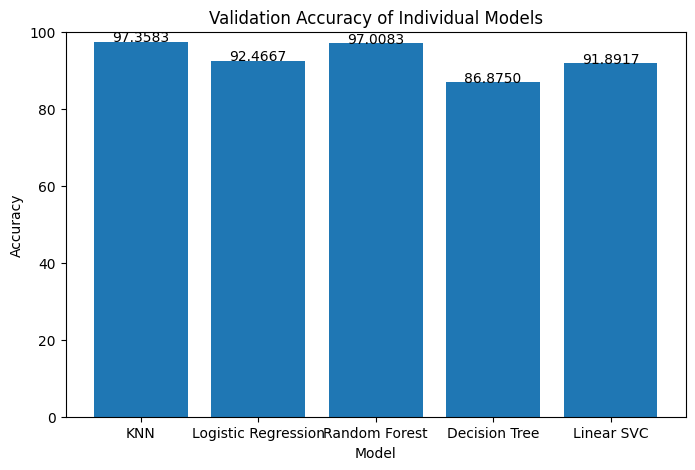

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["Validation Accuracy"]*100
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Validation Accuracy of Individual Models")
plt.ylim(0, 100)

for i, acc in enumerate(results_df["Validation Accuracy"]*100):
    plt.text(i, acc + 0.005, f"{acc:.4f}", ha='center')

plt.show()

##Accuracy + Error Rate Graph

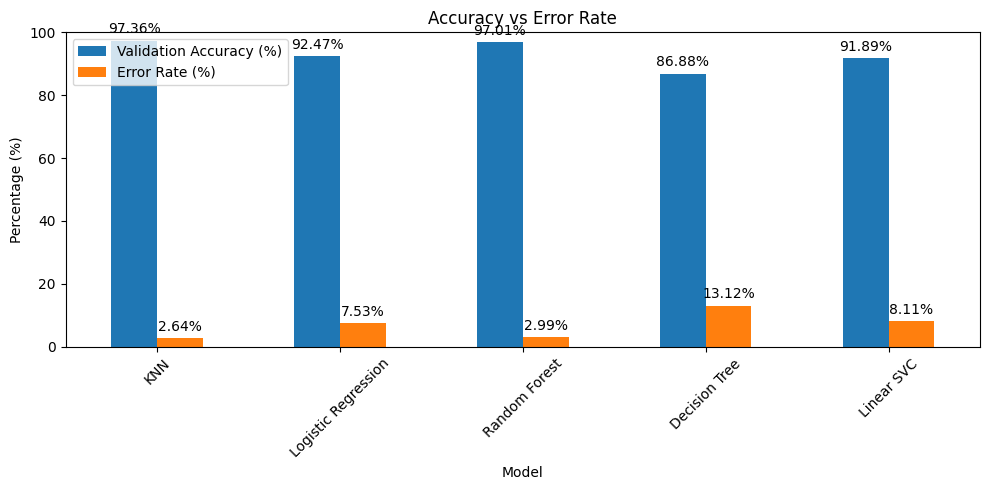

In [29]:
results_df["Validation Accuracy (%)"] = results_df["Validation Accuracy"] * 100
results_df["Error Rate (%)"] = 100 - results_df["Validation Accuracy (%)"]
ax = results_df.plot(
    x="Model",
    y=["Validation Accuracy (%)", "Error Rate (%)"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Accuracy vs Error Rate")
plt.ylabel("Percentage (%)")
plt.xlabel("Model")
plt.ylim(0, 100)
plt.xticks(rotation=45)

# Add labels on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

In [31]:
# 4. TRAINING THE STACKING ENSEMBLE
print("--- Phase 2: Building Stacking Ensemble ---")
tuned_base_models = [
    ('knn', best_knn),
    ('lr', best_lr),
    ('rf', best_rf),
    ('dt', best_dt),
    ('svc', best_svc)
]


meta_model = LogisticRegression(C=0.1, max_iter=1000, random_state=42)

# Building the stacking architecture
stacking_ensemble = StackingClassifier(
    estimators=tuned_base_models,
    final_estimator=meta_model,
    cv=3,
    passthrough=True,
    n_jobs=-1,
    verbose=2
)

print("Training Stacking Ensemble on training data...")
stacking_ensemble.fit(x_train, y_train)

--- Phase 2: Building Stacking Ensemble ---
Training Stacking Ensemble on training data...


StackingClassifier(cv=3,
                   estimators=[('knn',
                                KNeighborsClassifier(metric='euclidean',
                                                     n_jobs=-1,
                                                     weights='distance')),
                               ('lr',
                                LogisticRegression(C=0.1, max_iter=250,
                                                   n_jobs=-1,
                                                   random_state=42)),
                               ('rf',
                                RandomForestClassifier(max_depth=20,
                                                       n_estimators=200,
                                                       n_jobs=-1,
                                                       random_state=42)),
                               ('dt',
                                DecisionTreeClassifier(criterion='entropy',
                                                       max_depth=30,
                                                       min_samples_leaf=10,
                                                       min_samples_split=15,
                                                       random_state=42)),
                               ('svc',
                                LinearSVC(dual=True, loss='hinge',
                                          max_iter=5000, random_state=42))],
                   final_estimator=LogisticRegression(C=0.1, max_iter=1000,
                                                      random_state=42),
                   n_jobs=-1, passthrough=True, verbose=2)

##Stacking ensemble validation accuracy


In [33]:
y_pred_stack = stacking_ensemble.predict(x_val)

stack_acc = accuracy_score(y_val, y_pred_stack)

print(f"Stacking Ensemble Validation Accuracy: {stack_acc*100:.2f}%")

Stacking Ensemble Validation Accuracy: 98.09%


##Stacking Ensemble Validation Accuracy: 98.09%

In [34]:
 # 5. INDIVIDUAL VS. ENSEMBLE PERFORMANCE EVALUATION
from sklearn.metrics import accuracy_score
import pandas as pd

models = {
    "KNN": best_knn,
    "Logistic Regression": best_lr,
    "Random Forest": best_rf,
    "Decision Tree": best_dt,
    "Linear SVC": best_svc,
    "Stacking Ensemble": stacking_ensemble
}

test_results = []

for name, model in models.items():
    y_pred = model.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    test_results.append({
        "Model": name,
        "Test Accuracy (%)": acc * 100
    })

    print(f"{name}: {acc*100:.2f}%")

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values(
    by="Test Accuracy (%)",
    ascending=False
)

print(test_results_df)

KNN: 97.05%
Logistic Regression: 92.11%
Random Forest: 96.48%
Decision Tree: 87.43%
Linear SVC: 91.75%
Stacking Ensemble: 97.82%
                 Model  Test Accuracy (%)
5    Stacking Ensemble              97.82
0                  KNN              97.05
2        Random Forest              96.48
1  Logistic Regression              92.11
4           Linear SVC              91.75
3        Decision Tree              87.43


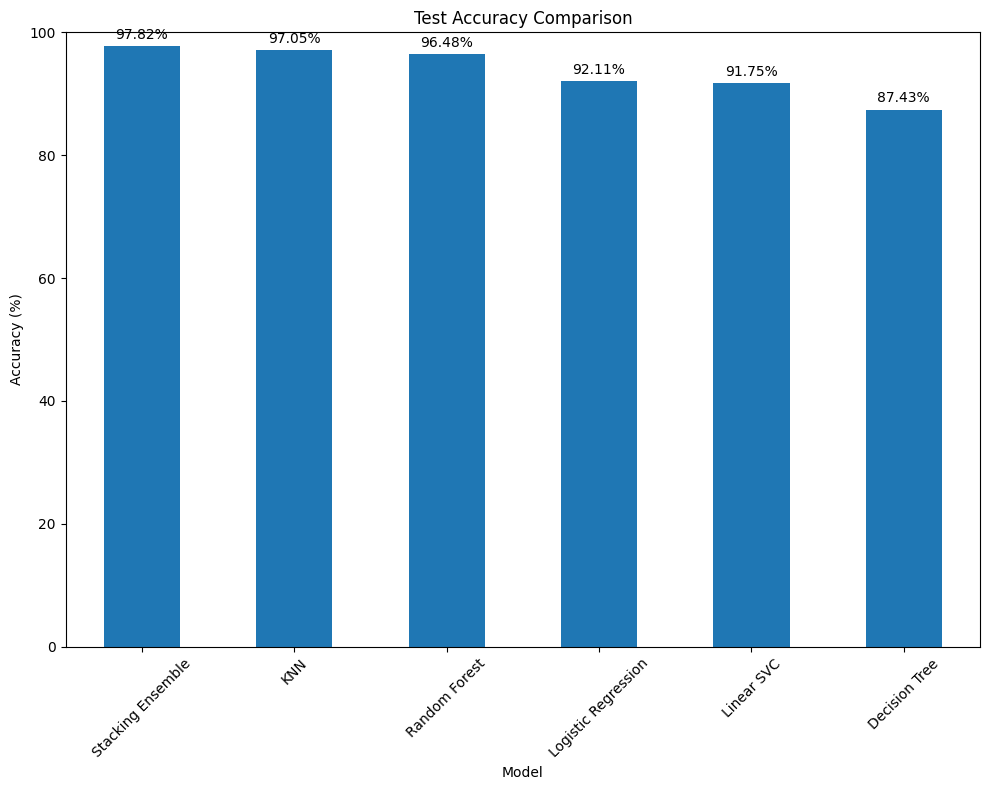

In [36]:
import matplotlib.pyplot as plt

ax = test_results_df.plot(
    x="Model",
    y="Test Accuracy (%)",
    kind="bar",
    figsize=(10,8),
    legend=False
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.ylim(0, 100)
plt.xticks(rotation=45)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

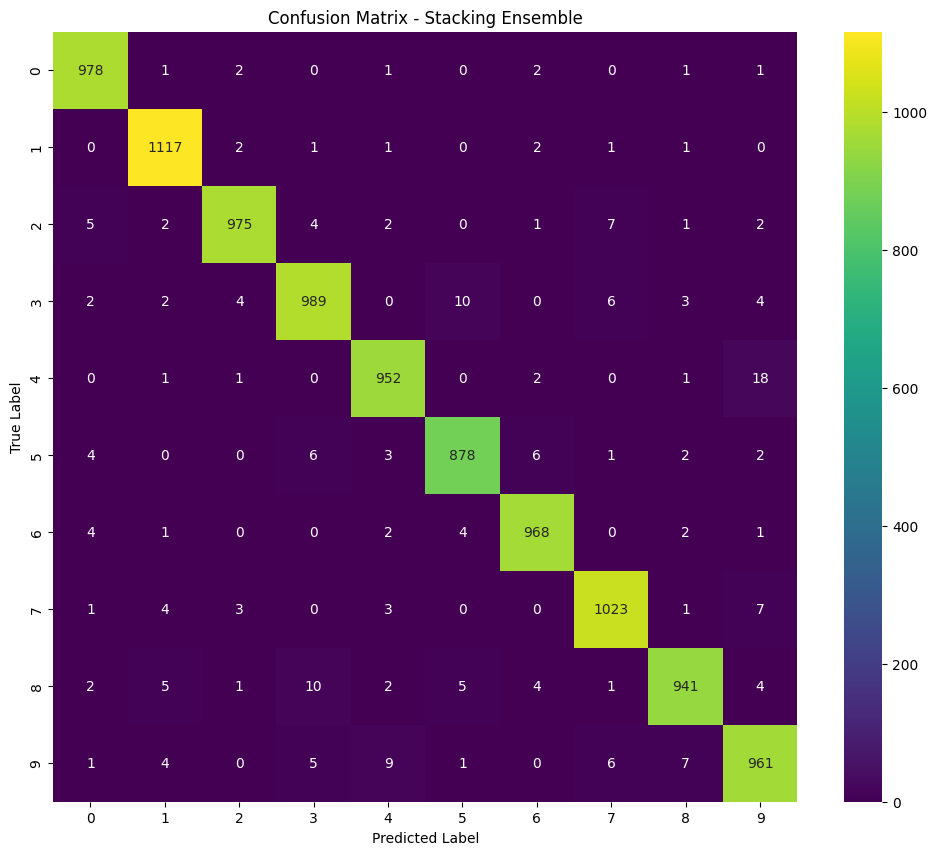

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       986
           1       0.98      0.99      0.99      1125
           2       0.99      0.98      0.98       999
           3       0.97      0.97      0.97      1020
           4       0.98      0.98      0.98       975
           5       0.98      0.97      0.98       902
           6       0.98      0.99      0.98       982
           7       0.98      0.98      0.98      1042
           8       0.98      0.97      0.97       975
           9       0.96      0.97      0.96       994

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [42]:
import seaborn as sns
y_pred_test = stacking_ensemble.predict(x_test)

cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='viridis',
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Stacking Ensemble")
plt.show()

print(classification_report(
    y_test,
    y_pred_test,
    target_names=[str(i) for i in range(10)]
))

In [154]:
sample = x_test.iloc[0].values.reshape(1,-1)

print("True:", y_test.iloc[0])
print("Pred:", stacking_ensemble.predict(sample)[0])
probs = stacking_ensemble.predict_proba(sample)[0]
for digit in np.argsort(probs)[::-1][:5]:
    print(f"Digit {digit}: {probs[digit]*100:.2f}%")

True: 7
Pred: 7


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dis

Digit 7: 99.45%
Digit 2: 0.17%
Digit 3: 0.10%
Digit 9: 0.10%
Digit 8: 0.09%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


In [167]:
from google.colab import files

uploaded = files.upload()

Saving digit_4.jpg to digit_4.jpg


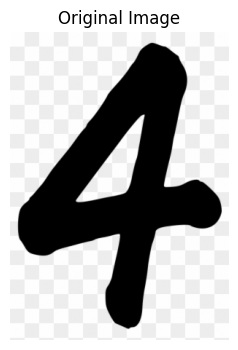

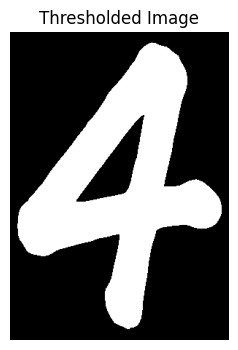

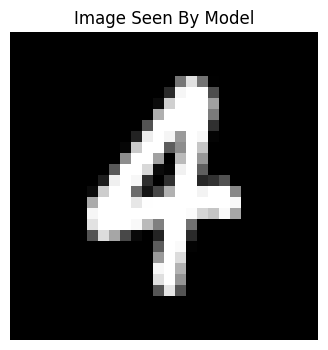

Predicted Digit: 4

Top Predictions:
Digit 4: 99.51%
Digit 9: 0.29%
Digit 7: 0.07%
Digit 3: 0.03%
Digit 2: 0.03%


In [168]:
from PIL import Image
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd


# LOAD IMAGE

img = Image.open("digit_4.jpg").convert("L")
img = np.array(img)

# Show original image
plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.show()


# INVERT COLORS
# White background + black digit
# becomes
# black background + white digit

img = 255 - img


# THRESHOLD

_, thresh = cv2.threshold(
    img,
    50,
    255,
    cv2.THRESH_BINARY
)

plt.figure(figsize=(4,4))
plt.imshow(thresh, cmap='gray')
plt.title("Thresholded Image")
plt.axis('off')
plt.show()

-
# FINDING DIGIT BOUNDING BOX

coords = cv2.findNonZero(thresh)

x, y, w, h = cv2.boundingRect(coords)

digit = thresh[y:y+h, x:x+w]


# RESIZE TO MNIST STYLE

target_size = 20

if h > w:
    new_h = target_size
    new_w = max(1, int(w * target_size / h))
else:
    new_w = target_size
    new_h = max(1, int(h * target_size / w))

digit = cv2.resize(
    digit,
    (new_w, new_h),
    interpolation=cv2.INTER_AREA
)


# CENTER ON 28x28 CANVAS

canvas = np.zeros((28,28), dtype=np.uint8)

x_offset = (28 - new_w) // 2
y_offset = (28 - new_h) // 2

canvas[
    y_offset:y_offset+new_h,
    x_offset:x_offset+new_w
] = digit


# SHOW FINAL IMAGE

plt.figure(figsize=(4,4))
plt.imshow(canvas, cmap='gray')
plt.title("Image Seen By Model")
plt.axis('off')
plt.show()


# NORMALIZE

img_array = canvas.astype(np.float32) / 255.0

# Flatten
img_flat = img_array.reshape(1, -1)

# If model was trained on DataFrame
img_df = pd.DataFrame(
    img_flat,
    columns=x_train.columns
)


# PREDICT

prediction = stacking_ensemble.predict(img_df)

print("Predicted Digit:", prediction[0])


# CONFIDENCE

probs = stacking_ensemble.predict_proba(img_df)[0]

print("\nTop Predictions:")

for digit in np.argsort(probs)[::-1][:5]:
    print(f"Digit {digit}: {probs[digit]*100:.2f}%")

In [182]:
import joblib

joblib.dump(stacking_ensemble, "stacking_ensemble_mnist.pkl")

['stacking_ensemble_mnist.pkl']

In [184]:
!ls -lh stacking_ensemble_mnist.pkl

-rw-r--r-- 1 root root 1020M Jun 14 07:05 stacking_ensemble_mnist.pkl
